# Laue Method Image Analysis

Using ImageIO to read in png and tiff images for LiF 100 and background images produced by Laue method. 

In [3]:
# Library imports
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt

In [4]:
img = iio.imread(r"C:\Users\joshb\OneDrive\PHYSICS BSc UNIVERSITY of EXETER\BSc Physics Stage 2\Practical Physics II\practical_physics_II\Lab_2_Bragg_Laue_Methods\Laue Images\LIF 100.png")

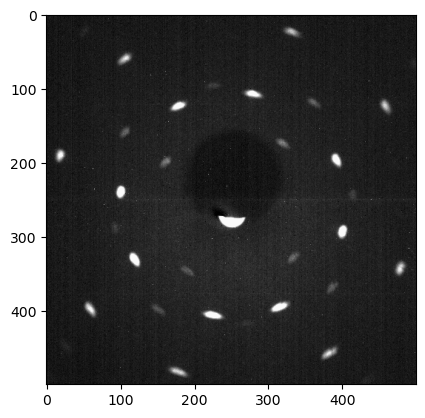

In [5]:
plt.imshow(img)

In [6]:
print(img.shape)

(500, 500, 3)


In [7]:
type(img)

numpy.ndarray

## Inspect image

Writing code that:
- Loads the image
- Prints shape and dtype
- Displays it

In [9]:
# Defining inspect() function
def inspect(imgfile):
    """
    Function that loads an image, prints shape and dtype, then displays it. 
    Uses imageio.v3 library.

    Parameters: 
     - imgfile (string): image file path

    Output: 
     - Image shape
     - Image dtype
     - Displays image
     """
    if isinstance(imgfile, str):
        # Read image file
        image = iio.imread(imgfile)

        # Print image shape and dtype
        print("Image shape:", image.shape)
        print("Image dtype:",image.dtype)

        # Display image (greyscale)
        plt.imshow(image, cmap="gray")
        plt.colorbar(label="Pixel intensity")
        plt.show()
        
    else:
        print("Error: image file path must be string")

#### LiF 100 & LiF 100b

Both images saved as png files. 

Image shape: (500, 500, 3)
Image dtype: uint8


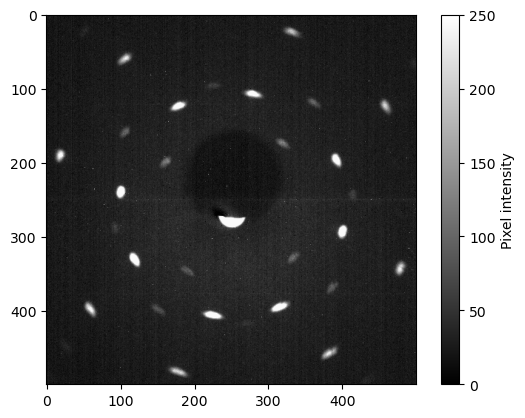

In [11]:
inspect(
    r"C:\Users\joshb\OneDrive\PHYSICS BSc UNIVERSITY of EXETER\BSc Physics Stage 2\Practical Physics II\practical_physics_II\Lab_2_Bragg_Laue_Methods\Laue Images\LIF 100.png"
    )

Image shape: (500, 500, 3)
Image dtype: uint8


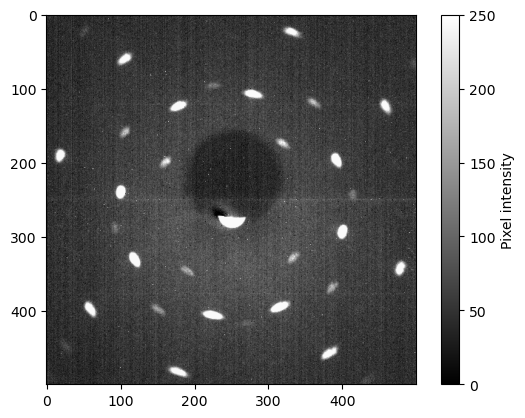

In [12]:
inspect(
    r"C:\Users\joshb\OneDrive\PHYSICS BSc UNIVERSITY of EXETER\BSc Physics Stage 2\Practical Physics II\practical_physics_II\Lab_2_Bragg_Laue_Methods\Laue Images\LIF 100b.png"
    )

#### background image LIF 100 and background image

Both saved as tif files. 

Image shape: (500, 500)
Image dtype: uint16


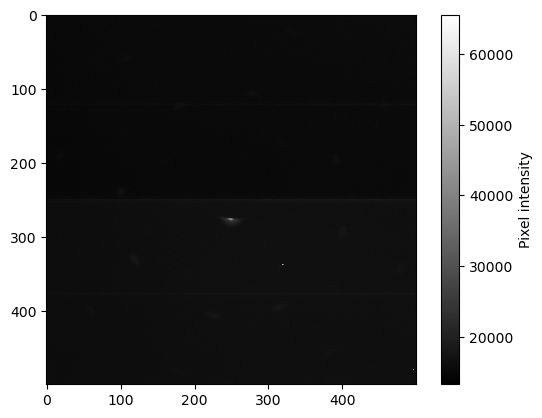

In [14]:
inspect(
    r"C:\Users\joshb\OneDrive\PHYSICS BSc UNIVERSITY of EXETER\BSc Physics Stage 2\Practical Physics II\practical_physics_II\Lab_2_Bragg_Laue_Methods\Laue Images\background image LIF 100.tif"
    )

Image shape: (500, 500)
Image dtype: uint16


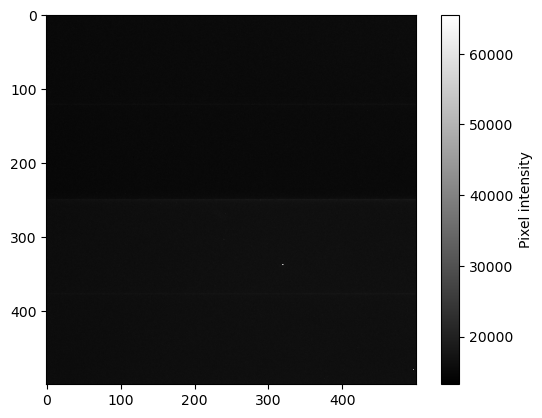

In [15]:
inspect(
    r"C:\Users\joshb\OneDrive\PHYSICS BSc UNIVERSITY of EXETER\BSc Physics Stage 2\Practical Physics II\practical_physics_II\Lab_2_Bragg_Laue_Methods\Laue Images\background image.tif"
    )

## png vs tif

Even though all three channels are identical:
- The PNG is uint8: 256 intensity levels
- The TIFF is uint16: 65,536 intensity levels

This means a factor of 256 loss in intensity resolution.

For Laue work:
- Centroid positions depend on relative intensity weighting
- Quantisation increases centroid uncertainty
- Background structure gets compressed

Therefore while I may use png for visualisations in report, I am going to use tifs for analysis. 

In [17]:
# Loading tif images only
LiF100_tif = iio.imread(
                r"C:\Users\joshb\OneDrive\PHYSICS BSc UNIVERSITY of EXETER\BSc Physics Stage 2\Practical Physics II\practical_physics_II\Lab_2_Bragg_Laue_Methods\Laue Images\background image LIF 100.tif"
                )

background_tif = iio.imread(
                r"C:\Users\joshb\OneDrive\PHYSICS BSc UNIVERSITY of EXETER\BSc Physics Stage 2\Practical Physics II\practical_physics_II\Lab_2_Bragg_Laue_Methods\Laue Images\background image.tif"
                )

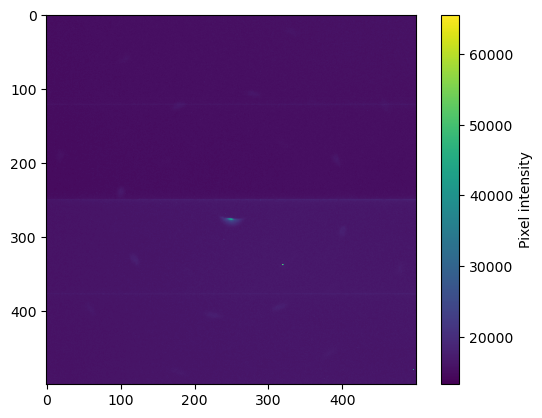

In [18]:
# Plot tif images
plt.imshow(LiF100_tif)
plt.colorbar(label="Pixel intensity")
plt.show()

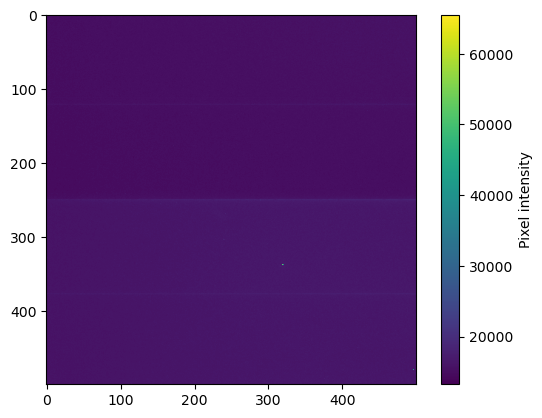

In [19]:
plt.imshow(background_tif)
plt.colorbar(label="Pixel intensity")
plt.show()

# 1. Offest (dark) subtraction

This is required, is it: 
- removed detector bias + vertical banding
- prevents fake spots
- makes intensity statistics meaningful

However, there is an error source introduced here. Detector noise contributes to uncertainty in spot centrioid (later). 

In [21]:
# convert to floats
I = LiF100_tif.astype(float)
B = background_tif.astype(float)

In [22]:
# Background correct
I_corr = I - B
I_corr[I_corr < 0] = 0

# Identify the beam center

Because the crystal is oriented along a high-symmetry direction ((100) for LiF), the pattern has: 
- 4-fold symmetry
- mirror symmetry in x and y

In [24]:
# Extract cooridnated of bright pixels
thresh = np.mean(I_corr) + 5*np.std(I_corr) # noise based threshold
ys, xs = np.where(I_corr > thresh)

#### Take the median 
Taking the median (instead of the mean) of these bright pixels because it is robust against outliers, and insensitive to one strong spot or the beamstop artefact. 

In [26]:
# Take the median
yc = np.median(ys)
xc = np.median(xs)

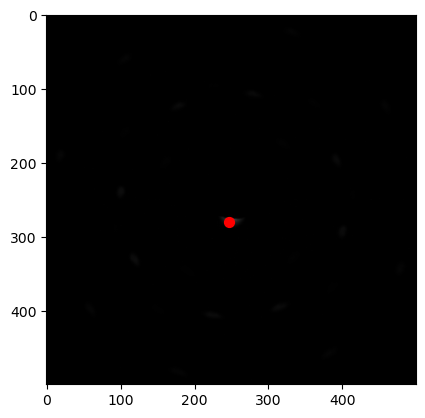

In [27]:
# Visual check
# Beam centre uncertainty estimated as ±2 pixels due to
# finite spot size and thresholding ambiguity
plt.imshow(I_corr, cmap="gray")
plt.scatter(xc, yc, c="r", s=50)
plt.show()

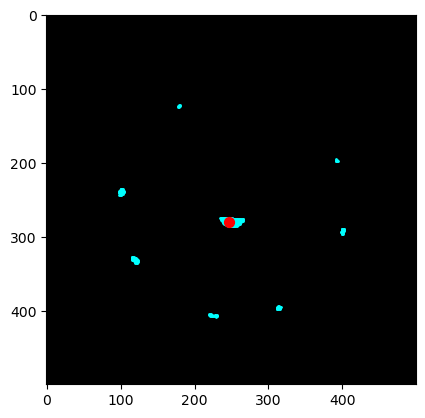

In [28]:
# Visualisation. Doesn't affect data
plt.imshow(I_corr, cmap="gray",
           vmin=thresh,
           vmax=thresh + 0.1*np.max(I_corr))
plt.scatter(xs, ys, s=1, c="cyan")
plt.scatter(xc, yc, c="red", s=50)
plt.show()

I in this last visualisation, there are fewer spots than appeared on the png images. What is displayed in blue is just what is over a noise threshhold. Thus it only keeps very strong signal, and rejects weak reflections, tails of spots and spots close to background noise. 

However, the central bright region contaminates things. So I'm going to mask it. 

In [30]:
# distances from final beam centre
r = np.sqrt((ys - yc)**2 + (xs - xc)**2)

In [31]:
# exclude central beamstop region
mask = r > 30   # pixels, justified by inspection

In [32]:
ys = ys[mask]
xs = xs[mask]

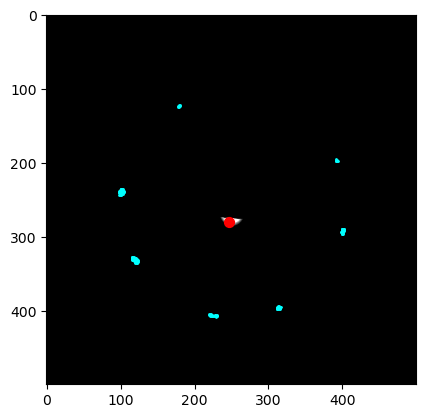

In [33]:
# Corrected visualisation
plt.imshow(I_corr, cmap="gray",
           vmin=thresh,
           vmax=thresh + 0.1*np.max(I_corr))
plt.scatter(xs, ys, s=1, c="cyan")
plt.scatter(xc, yc, c="red", s=50)
plt.show()

Now the beam centre is essentially correct, with the red dot not being defined by central blob (can still see central blob, it is no longer cyan so not included in data). 

Now I am going to group nearby cyan pixels into individual diffraction spots. 

In [35]:
from scipy.ndimage import label

In [36]:
# Grouping spots
binary = np.zeros_like(I_corr, dtype=bool)
binary[ys, xs] = True

In [37]:
labels, nspots = label(binary)
print("Number of spots:", nspots)

Number of spots: 7


Code has identified 7 spots. Now i am going to compute the center of these spots. I think weighing them by intensity is best as tif files have such good data. 

In [39]:
# Empty array for storing centroid data. 
centroids = []

In [40]:
# Find centroids for every spot
for i in range(1, nspots+1):
    spot_ys, spot_xs = np.where(labels == i)
    weights = I_corr[spot_ys, spot_xs]

    # If spots are too small/noise fragments/badly thresholded, skip
    if len(weights) < 10:
        continue

    y_bar = np.sum(spot_ys * weights) / np.sum(weights)
    x_bar = np.sum(spot_xs * weights) / np.sum(weights)

    centroids.append((y_bar, x_bar))

In [41]:
# Remove duplicate centroids (arising from split components)
centroids = list(set(centroids))

In [42]:
print(centroids)

[(330.9939927246644, 119.11019315503637), (239.16508096176145, 100.86511030079495), (406.41554420188885, 225.08307787583217), (395.7383398276066, 313.6725311921911), (292.40586772245064, 400.17765595655044)]


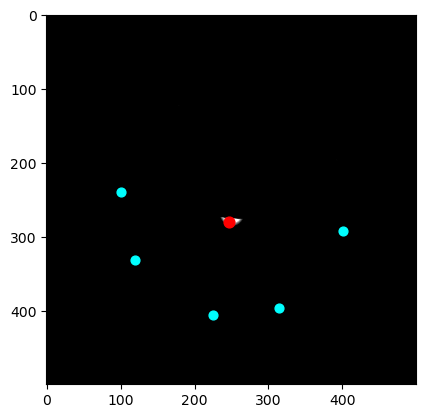

In [43]:
# Visualisation for sanity check 
ys_c, xs_c = zip(*centroids)

plt.imshow(I_corr, cmap="gray",
           vmin=thresh,
           vmax=thresh + 0.1*np.max(I_corr))
plt.scatter(xs_c, ys_c, c="cyan", s=40)
plt.scatter(xc, yc, c="red", s=60)
plt.show()

The centroids are not randomly scattered: they lie on a rough ring around the red central point. However they are positioned asymmetrically around the beam center. 

I have 5 centroids with my chosen thresholds. However, 100 LiF pattern has fourfold symmetry. So why don't I see all the spots? 

My thresholds are deliberately conservative. I'm selecting high-SNR (signal to noise ratio) reflections only. Some of the spots visible in the PNG files are too weak in TIFF files. 

I am not trying to detect all spots, I'm trying to extract accurate angles from a subset. 

Now trying to find the pixel offsets from beam center.

In [46]:
# Create array for pixel offsets
offsets = []

In [47]:
# Calculate offsets for each centroid
for (y_bar, x_bar) in centroids:
    dy = y_bar - yc
    dx = x_bar - xc
    offsets.append((dy, dx))

In [48]:
print(offsets)

[(50.993992724664395, -127.88980684496363), (-40.83491903823855, -146.13488969920505), (126.41554420188885, -21.916922124167826), (115.73833982760658, 66.67253119219112), (12.405867722450637, 153.17765595655044)]


Now converting pixel offsets to meters.

1 pixel = 96 µm (lab book documentation for XRIS detector) 

In [50]:
# Defining pixel size in meters
pixel_size = 96e-6  # m

In [51]:
# Finding radial distance on detector in meters
L = []

for (dy, dx) in offsets:
    L.append(np.sqrt(dx**2 + dy**2) * pixel_size)

In [52]:
print(L)

[0.013217422098775453, 0.014566365884048799, 0.012316931425489888, 0.01282259236170631, 0.01475320423873008]


Now finding scattering angles. Converting each $L_i$ into a Bragg angle using the experiment geometry: 

$$
\theta = \frac{1}{2} \tan^{-1}\left({\frac{L_i}{D}}\right) 
$$

where D is crystal-detector distance measured in lab. 

In [54]:
# Defining crystal-detector distance: SDD set to 90mm
D = 90e-3 # m

In [55]:
# Calculating scattering angles
L = np.array(L)
theta = 0.5 * np.arctan(L / D)

In [56]:
print(theta)
print(sorted(np.degrees(theta)))

[0.07290894 0.08022855 0.06800494 0.07076041 0.08123972]
[3.8963958514559556, 4.054272789315167, 4.177374486841732, 4.596757591993742, 4.654692927722419]


In [57]:
# Computing ratio of each angle to minimum angle: 
sin_exp = np.sin(theta)
rat_exp = sin_exp / np.min(sin_exp)
print(np.sort(rat_exp))

[1.         1.04045238 1.07198893 1.17938969 1.19422165]


Each value of $\theta$ corresponds to one diffracting set of lattice planes satisfying Bragg's Law for some wavelength in the white X-ray spectrum. In the Laue method, $\lambda$ is not known. Must infer indices using geometry and symmetry, not wavelength. 

## Miller indexing by elimination

For a cubic crystal (LiF, FCC), the Laue condition gives (lab manual): 

$$
\sin \theta \approx \frac{h}{\sqrt{h^2 + k^2 + l^2}} 
$$

with FCC selection rules: 
- $h,k,l$, all odd or all even
- no mixed parity

In [60]:
# Computing sin thta for each measured angle
sin_angle = []

for angle in theta: 
    sin_angle.append(np.sin(angle))

In [61]:
print(sin_angle)

[0.07284436221327976, 0.08014251579057613, 0.0679525319406221, 0.07070137374943802, 0.08115038452039873]


I'm going to compute sin theta ratios for all allowed Miller indices up to a maximum. 

In [63]:
def gen_hkl(max_index=4):
    """
    Generate lowest-order allowed Miller indices for an FCC crystal.
    Only even indices are included to enforce FCC selection rules.
    """

    hkls = []
    for h in range(0, max_index+1):
        for k in range(0, h+1):
            for l in range(0, k+1):
                if (h,k,l) == (0,0,0):
                    continue
                # FCC rule: all even or all odd
                if (h%2, k%2, l%2) not in [(0,0,0), (1,1,1)]:
                    continue
                hkls.append((h,k,l))
    return hkls

While a triple nested loop is not good programming practice generally, I chose to use this method for simplicity and clarity. Runtime is negligible.  

In [65]:
def sin_theta_theory(hkl):
    """
    Function to calulate the theoretical sin theta ratio for given Miller indices hkl. 

    Parameters: 
    hkl (array): miller indices

    Returns: 
    sin_theta_val (float): for theoretical Bragg angle. 
    """
    h, k, l = hkl
    
    sin_theta_val = np.sqrt(h**2 + k**2 + l**2) 

    return sin_theta_val

In [66]:
def sin_theta_ratios(hkls, ref = (2,0,0)): 
    """
    Function to compute ratios relative to the smallest angle. 

    Paramaters: 
    hkls (array): Miller indices values

    Returns: 
    values: ratios 
    """
    
    ref_val = sin_theta_theory(ref)
    return np.array([sin_theta_theory(hkl)/ref_val for hkl in hkls])

Now to put these functions together and inspect: 

In [68]:
# Compute hkls and ratios relative to smallest angle
hkls = gen_hkl(max_index=6)
ratios = sin_theta_ratios(hkls)

In [69]:
ratios_unique = np.unique(np.round(ratios, 3))
print(ratios_unique)

[0.866 1.    1.414 1.658 1.732 2.    2.179 2.236 2.449 2.598 2.828 2.958
 3.    3.162 3.279 3.317 3.464 3.571 3.606 3.742 3.841 4.123 4.243 4.33
 4.359 4.69  5.196]


In [70]:
ref = (2,0,0)
ratio_to_hkls = {}

for hkl in hkls:
    r = round(sin_theta_theory(hkl) / sin_theta_theory(ref), 3)
    ratio_to_hkls.setdefault(r, []).append(hkl)

for r in sorted(ratio_to_hkls):
    print(f"{r:.3f} -> {ratio_to_hkls[r]}")


0.866 -> [(1, 1, 1)]
1.000 -> [(2, 0, 0)]
1.414 -> [(2, 2, 0)]
1.658 -> [(3, 1, 1)]
1.732 -> [(2, 2, 2)]
2.000 -> [(4, 0, 0)]
2.179 -> [(3, 3, 1)]
2.236 -> [(4, 2, 0)]
2.449 -> [(4, 2, 2)]
2.598 -> [(3, 3, 3), (5, 1, 1)]
2.828 -> [(4, 4, 0)]
2.958 -> [(5, 3, 1)]
3.000 -> [(4, 4, 2), (6, 0, 0)]
3.162 -> [(6, 2, 0)]
3.279 -> [(5, 3, 3)]
3.317 -> [(6, 2, 2)]
3.464 -> [(4, 4, 4)]
3.571 -> [(5, 5, 1)]
3.606 -> [(6, 4, 0)]
3.742 -> [(6, 4, 2)]
3.841 -> [(5, 5, 3)]
4.123 -> [(6, 4, 4)]
4.243 -> [(6, 6, 0)]
4.330 -> [(5, 5, 5)]
4.359 -> [(6, 6, 2)]
4.690 -> [(6, 6, 4)]
5.196 -> [(6, 6, 6)]


Compared to experimental ratios: 

1.0, 1.0405187111058591, 1.0721124459879465, 1.1797460440976715, 1.1946149993931219

Looks like (2,2,2), (6,6,5), (6,6,4), (6,5,4), (6,6,2)